In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = sns.load_dataset("titanic")
print(df.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


Identifying and Counting missing values 

In [4]:
print(df.isnull().sum())
print("Total missing:", df.isnull().sum().sum())

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64
Total missing: 869


a. Drop duplicate rows.

In [5]:
df = df.drop_duplicates()

b. Detect the outliers and remove the rows having more than two outliers identified using boxplot.

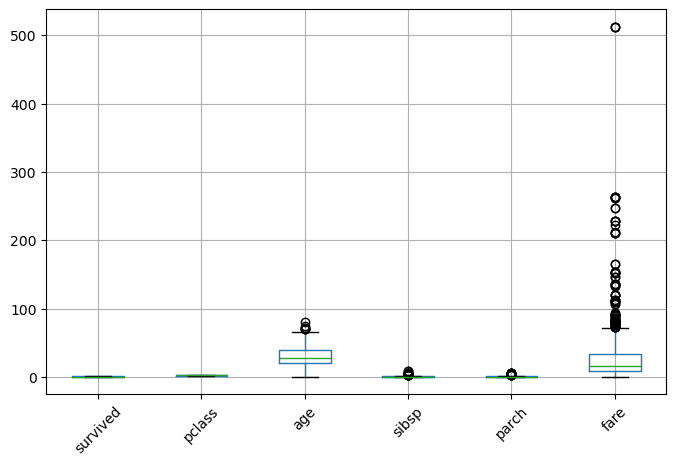

0      0
1      0
2      0
3      0
4      0
      ..
885    1
887    0
888    0
889    0
890    0
Name: outlier_count, Length: 784, dtype: int64
     survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0           0       3    male  22.0      1      0   7.2500        S  Third   
1           1       1  female  38.0      1      0  71.2833        C  First   
2           1       3  female  26.0      0      0   7.9250        S  Third   
3           1       1  female  35.0      1      0  53.1000        S  First   
4           0       3    male  35.0      0      0   8.0500        S  Third   
..        ...     ...     ...   ...    ...    ...      ...      ...    ...   
885         0       3  female  39.0      0      5  29.1250        Q  Third   
887         1       1  female  19.0      0      0  30.0000        S  First   
888         0       3  female   NaN      1      2  23.4500        S  Third   
889         1       1    male  26.0      0      0  30.0000        C  First

In [6]:
num = df.select_dtypes(include=np.number)

outlier = pd.DataFrame(False, index=df.index, columns=num.columns)

for c in num.columns:
    q1 = num[c].quantile(0.25)
    q3 = num[c].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    outlier[c] = (num[c] < low) | (num[c] > high)

plt.figure(figsize=(8,5))
df.select_dtypes(include=np.number).boxplot()
plt.xticks(rotation=45)
plt.show()

df["outlier_count"] = outlier.sum(axis=1)
print(df["outlier_count"])
df = df[df["outlier_count"] <= 2]
df = df.drop(columns=["outlier_count"])
print(df)

c. Identify the most positively correlated attributes and the most negatively correlated attributes.

Highest positive correlation: 0.38143286323904924
Highest negative correlation: -0.5492162083667462


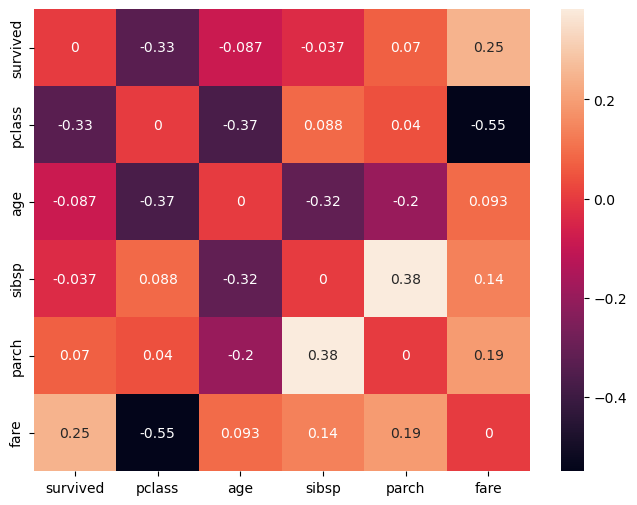

In [10]:
corr = df.select_dtypes(include=np.number).corr()

np.fill_diagonal(corr.values, 0)

max_corr = corr.max().max()
min_corr = corr.min().min()

print("Highest positive correlation:", max_corr)
print("Highest negative correlation:", min_corr)


plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True)
plt.show()

